In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

# Set the plot style for better aesthetics
plt.style.use('fivethirtyeight')

# This magic command is for Jupyter notebooks to display plots inline
%matplotlib inline

import yfinance as yf
import datetime as dt

# Define the stock ticker symbol
stock = "GOOG"

# Set the date range for the data
start = dt.datetime(2015, 1, 1)
end = dt.datetime(2025, 1, 1)

# Download the historical stock data from Yahoo Finance
df = yf.download(stock, start, end)

# Display the first few rows to check the downloaded data
df.head()

/tmp/ipykernel_511/1076207752.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2015-01-02,25.939945,26.259247,25.904852,26.147540,28951268
2015-01-05,25.399214,25.916224,25.359179,25.863336,41196796
2015-01-06,24.810535,25.513146,24.765558,25.455068,57998800
2015-01-07,24.768028,25.071709,24.696358,25.059648,41301082
2015-01-08,24.846125,24.885666,24.268813,24.614310,67071641


In [7]:
# Show the last 5 rows of the dataset to see the most recent data
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2024-12-24,196.546997,196.646470,194.187270,195.154237,6809800
2024-12-26,196.079422,197.133931,194.855780,195.721285,7907900
2024-12-27,193.035263,195.780982,190.977978,195.452689,14693000
2024-12-30,191.692261,192.776613,189.374324,189.876714,12209500
2024-12-31,189.453903,192.249351,188.598356,191.448526,14355200


In [8]:
# Show concise summary including data types, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   2516 non-null   float64
 1   (High, GOOG)    2516 non-null   float64
 2   (Low, GOOG)     2516 non-null   float64
 3   (Open, GOOG)    2516 non-null   float64
 4   (Volume, GOOG)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [15]:
df.describe()


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,82.088515,82.919400,81.227782,82.037644,3.077548e+07
std,44.203586,44.683301,43.736024,44.183641,1.536731e+07
min,24.345425,24.514763,24.098782,24.449225,6.809800e+06
25%,46.069691,46.317506,45.775227,46.084933,2.121900e+07
50%,64.117443,64.521389,63.440664,63.994525,2.701925e+07
75%,119.936066,121.226189,119.042927,119.966780,3.569050e+07
max,197.133957,201.829504,195.671553,197.502022,2.232980e+08


In [16]:
# Check for missing values in each column
df.isnull().sum()

,,0
Price,Ticker,
Close,GOOG,0
High,GOOG,0
Low,GOOG,0
Open,GOOG,0
Volume,GOOG,0


In [21]:
import plotly.graph_objects as go

# Candlestick Chart for stock price visualization

fig = go.Figure(data=[go.Candlestick(x = df['Date'], open = df['Open'],
                                    high = df['High'],
                                    low = df['Low'],
                                    close = df['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


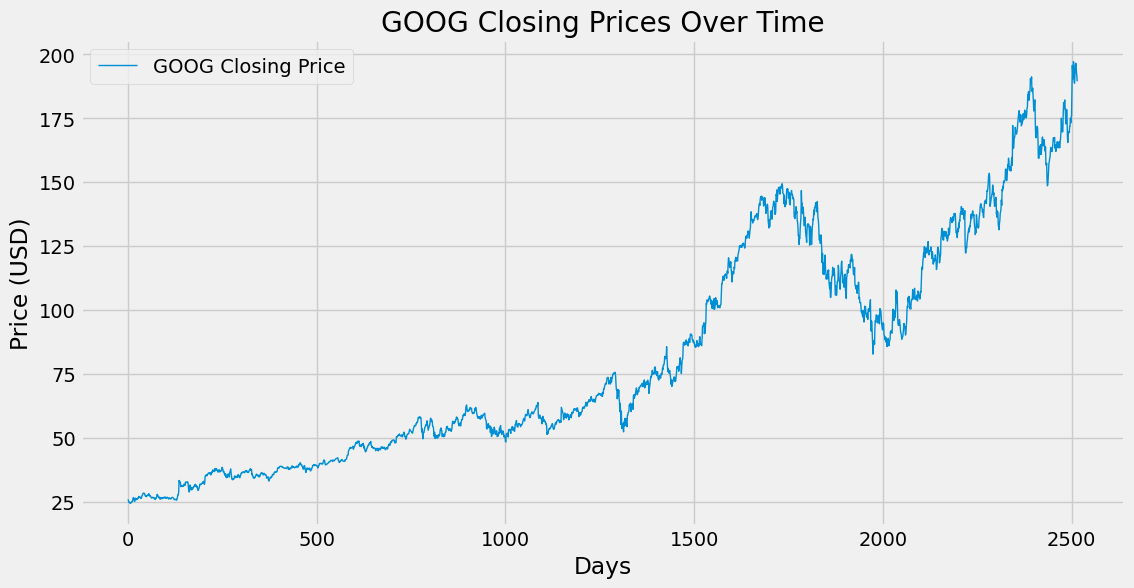

In [22]:
# Plot Closing Price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{stock} Closing Price', linewidth=1)
plt.title(f'{stock} Closing Prices Over Time')
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Split the closing price data into training (first 70%) and testing (last 30%) sets
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):])
print("Training data shape:", data_training.shape)
print("Testing data shape:", data_testing.shape)
# Scale the training data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_training_array = scaler.fit_transform(data_training)
print("Scaled training data shape:", data_training_array.shape)
data_training_array.shape[0]

Training data shape: (1761, 1)
Testing data shape: (755, 1)
Scaled training data shape: (1761, 1)


1761

In [35]:
# Prepare the training sequences
x_train = []
y_train = []

# For each entry, use the previous 100 days' closing prices as input (x), and the next day's price as output (y)
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])


x_train, y_train = np.array(x_train), np.array(y_train)

print("x_train shape (samples, time steps, features):", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape (samples, time steps, features): (1661, 100, 1)
y_train shape: (1661,)


In [37]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

# Initialize the model
model = Sequential()

# Add LSTM and Dropout layers
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=1))

# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, epochs=50)

# Get the last 100 days from training and concatenate with testing data
past_100_days = data_training.tail(100)

# Use pd.concat() instead of .append() to combine the dataframes
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - loss: 0.0322
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - loss: 0.0079
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - loss: 0.0052
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - loss: 0.0049
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 215ms/step - loss: 0.0045
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - loss: 0.0042
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - loss: 0.0038
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - loss: 0.0036
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - loss: 0.0037
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0035
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0033
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - loss: 0.0037
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 0.0037
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - loss: 0.0036
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/st

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
Shape of predictions: (755, 1)


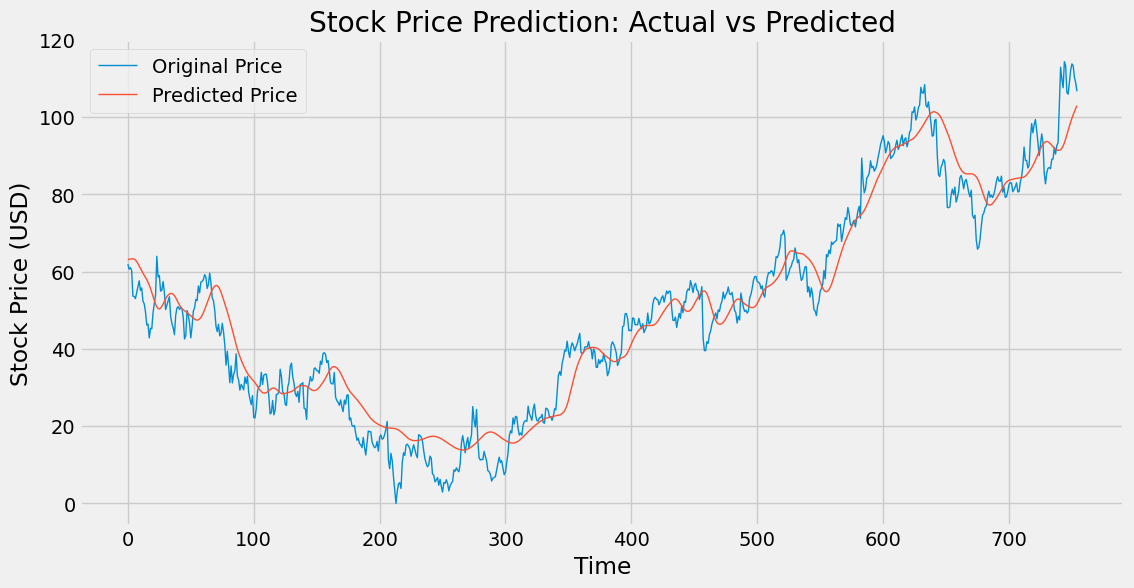

Model saved as stock_dl_model.h5


In [39]:
# Prepare test input
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
# Predict prices
y_predicted = model.predict(x_test)
print("Shape of predictions:", y_predicted.shape)

# Get the scaler's scale parameter for reverse transformation
scaler_scale = scaler.scale_

# Adjust the scale factor (ensure this matches your scaler settings)
scaler_factor = 1 / scaler_scale[0]
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Original Price', linewidth=1)
plt.plot(y_predicted, label='Predicted Price', linewidth=1)
plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

model.save('stock_dl_model.h5')
print("Model saved as stock_dl_model.h5")